In [1]:
# Import packages
from pathlib import Path

PROJECT_DIR = Path("/home/mcaskey/10XvParse/")
ANALYSIS_NAME = "Analysis_6"
SPECIES = "human"
INDEX_DIR = PROJECT_DIR / "Index" / SPECIES
ANALYSIS_DIR = Path.cwd()
CUTOFFS = [1000, 400, 400, 400]
FULL_GENE_INFO_PATH = Path("gene_data/gene_comparisons.csv")

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scrublet as scr
import pandas as pd
import anndata as ad
import scanpy as sc

from XvP_utils import plotting

In [3]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [4]:
# # In case you change the package
# import importlib
# importlib.reload(plotting)

In [5]:
data_10x = plotting.init_processing(analysis_name=ANALYSIS_NAME, project_dir=PROJECT_DIR, data_name='10x', assay ="10x", data_title='10X Genomics')
data_polyT = plotting.init_processing(analysis_name=ANALYSIS_NAME, project_dir=PROJECT_DIR, data_name='polyT', assay="parse", data_title="Parse 3'")
data_randO = plotting.init_processing(analysis_name=ANALYSIS_NAME, project_dir=PROJECT_DIR, data_name='randO', assay="parse", data_title='Parse Random Oligo')
data_parse = plotting.init_processing(analysis_name=ANALYSIS_NAME, project_dir=PROJECT_DIR, data_name='parse', assay="parse", data_title='Parse', modified=True)

raw_datasets = [data_10x, data_polyT, data_randO, data_parse]

# Population Upsampling Estimation

In [6]:
# Launches PreSeq in the background — does not block the notebook.
# Rerun plot_upsample() in a later cell once jobs complete.
# plotting.upsample(raw_datasets, Path("preseq"), overwrite=False)
# plotting.plot_upsample(raw_datasets, Path("preseq"), xlim=5e8, ylim=8e4)

# Quality Control Comparison

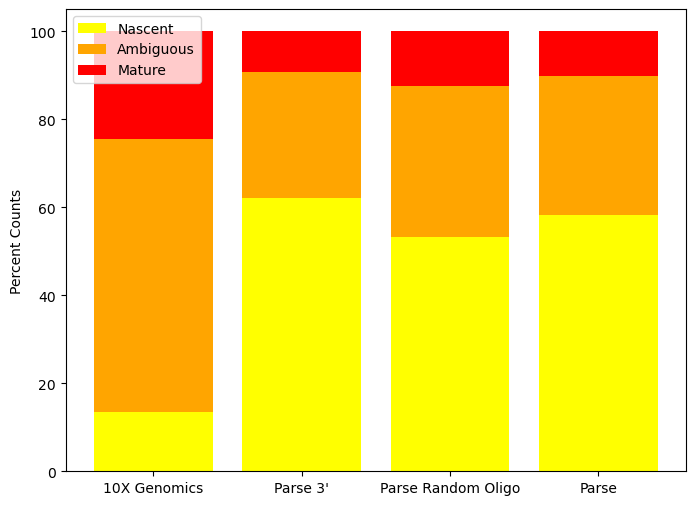

In [7]:
plotting.plot_nascent_mature_ratios(raw_datasets)

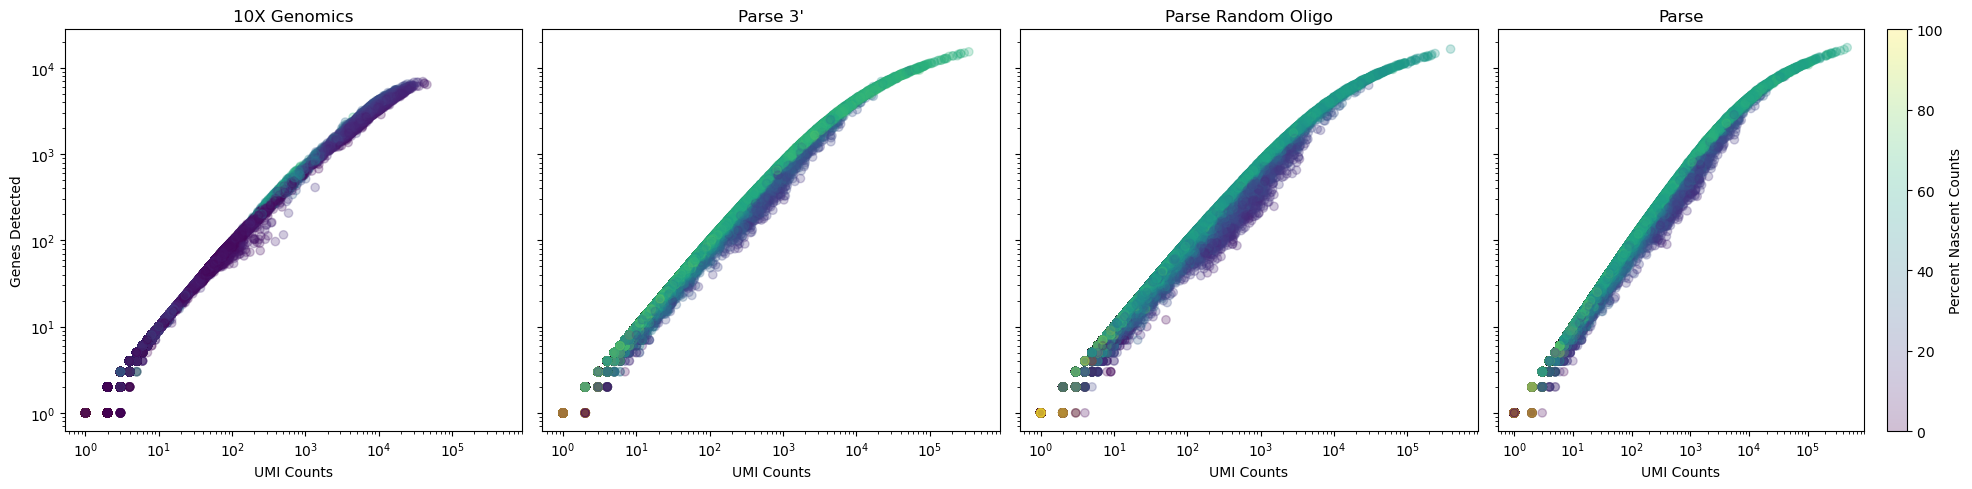

In [8]:
plotting.scatter_reads(raw_datasets)

In [9]:
gene_info = plotting.query_ensembl(PROJECT_DIR, index_dir=INDEX_DIR, species=SPECIES, overwrite=True)

In [10]:
for data in raw_datasets:
    plotting.add_cell_metrics(data, gene_info)

/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


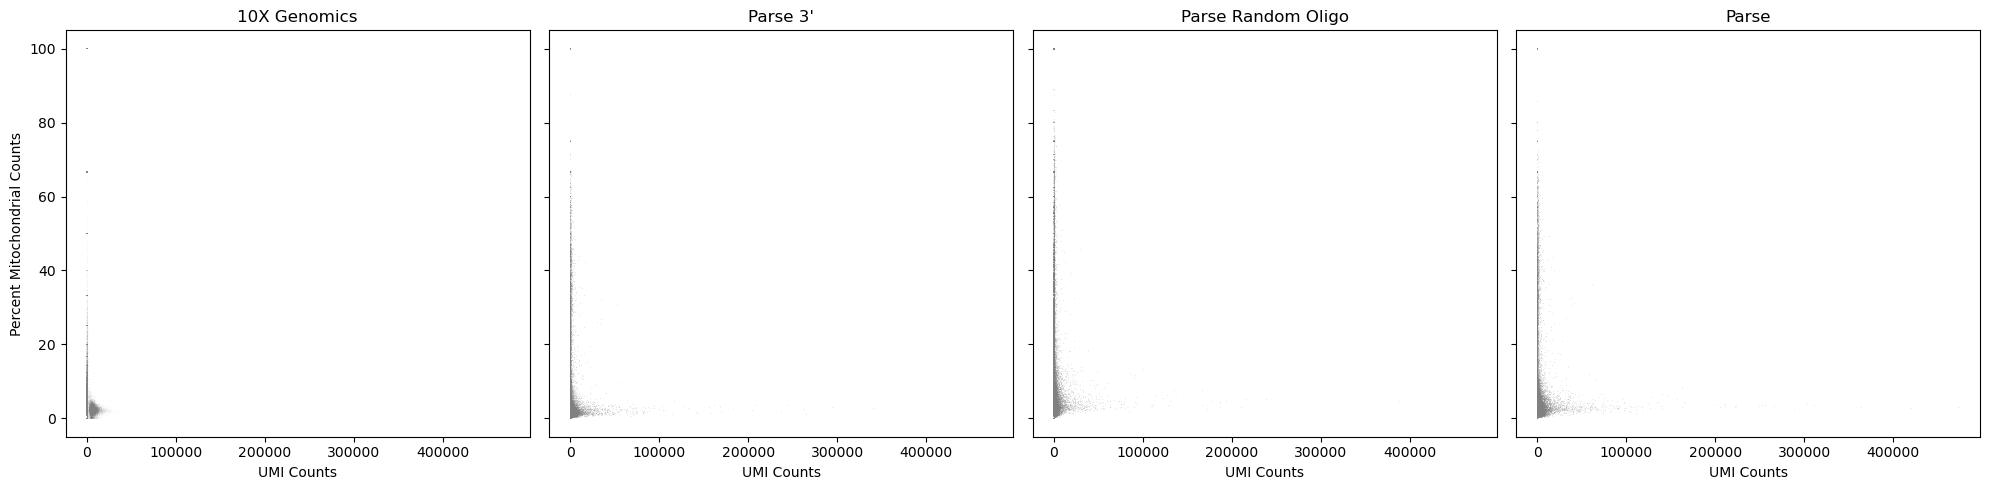

In [11]:
plotting.mito_scatter(raw_datasets)

13,081 cells passed the 1000 UMI threshold for 10X Genomics


10,261 cells passed the 400 UMI threshold for Parse 3'


9,042 cells passed the 400 UMI threshold for Parse Random Oligo


10,798 cells passed the 400 UMI threshold for Parse


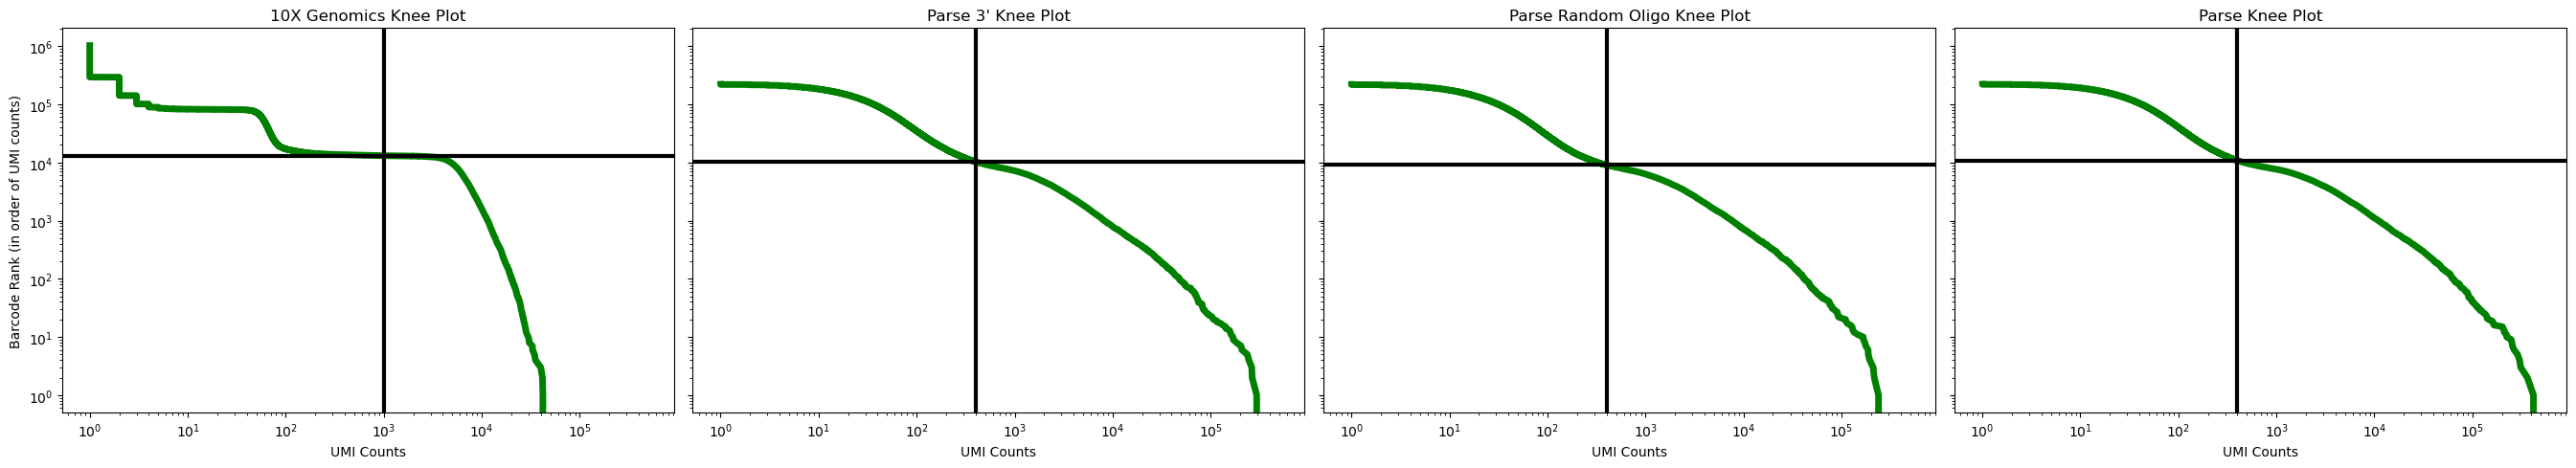

In [12]:
datasets = plotting.knee_plot(raw_datasets, cutoffs=CUTOFFS)

In [13]:
gene_info = plotting.update_gene_info(gene_info, datasets, FULL_GENE_INFO_PATH)

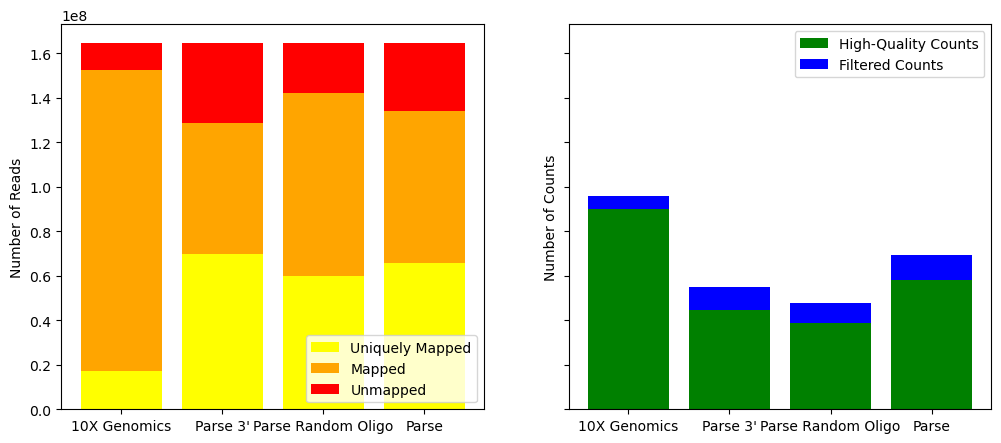

In [14]:
plotting.plot_filtering_metrics(datasets)

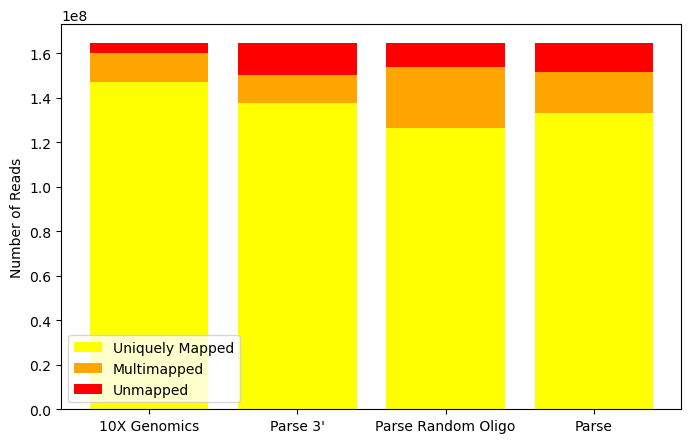

In [15]:
plotting.plot_filtering_metrics_star(datasets)

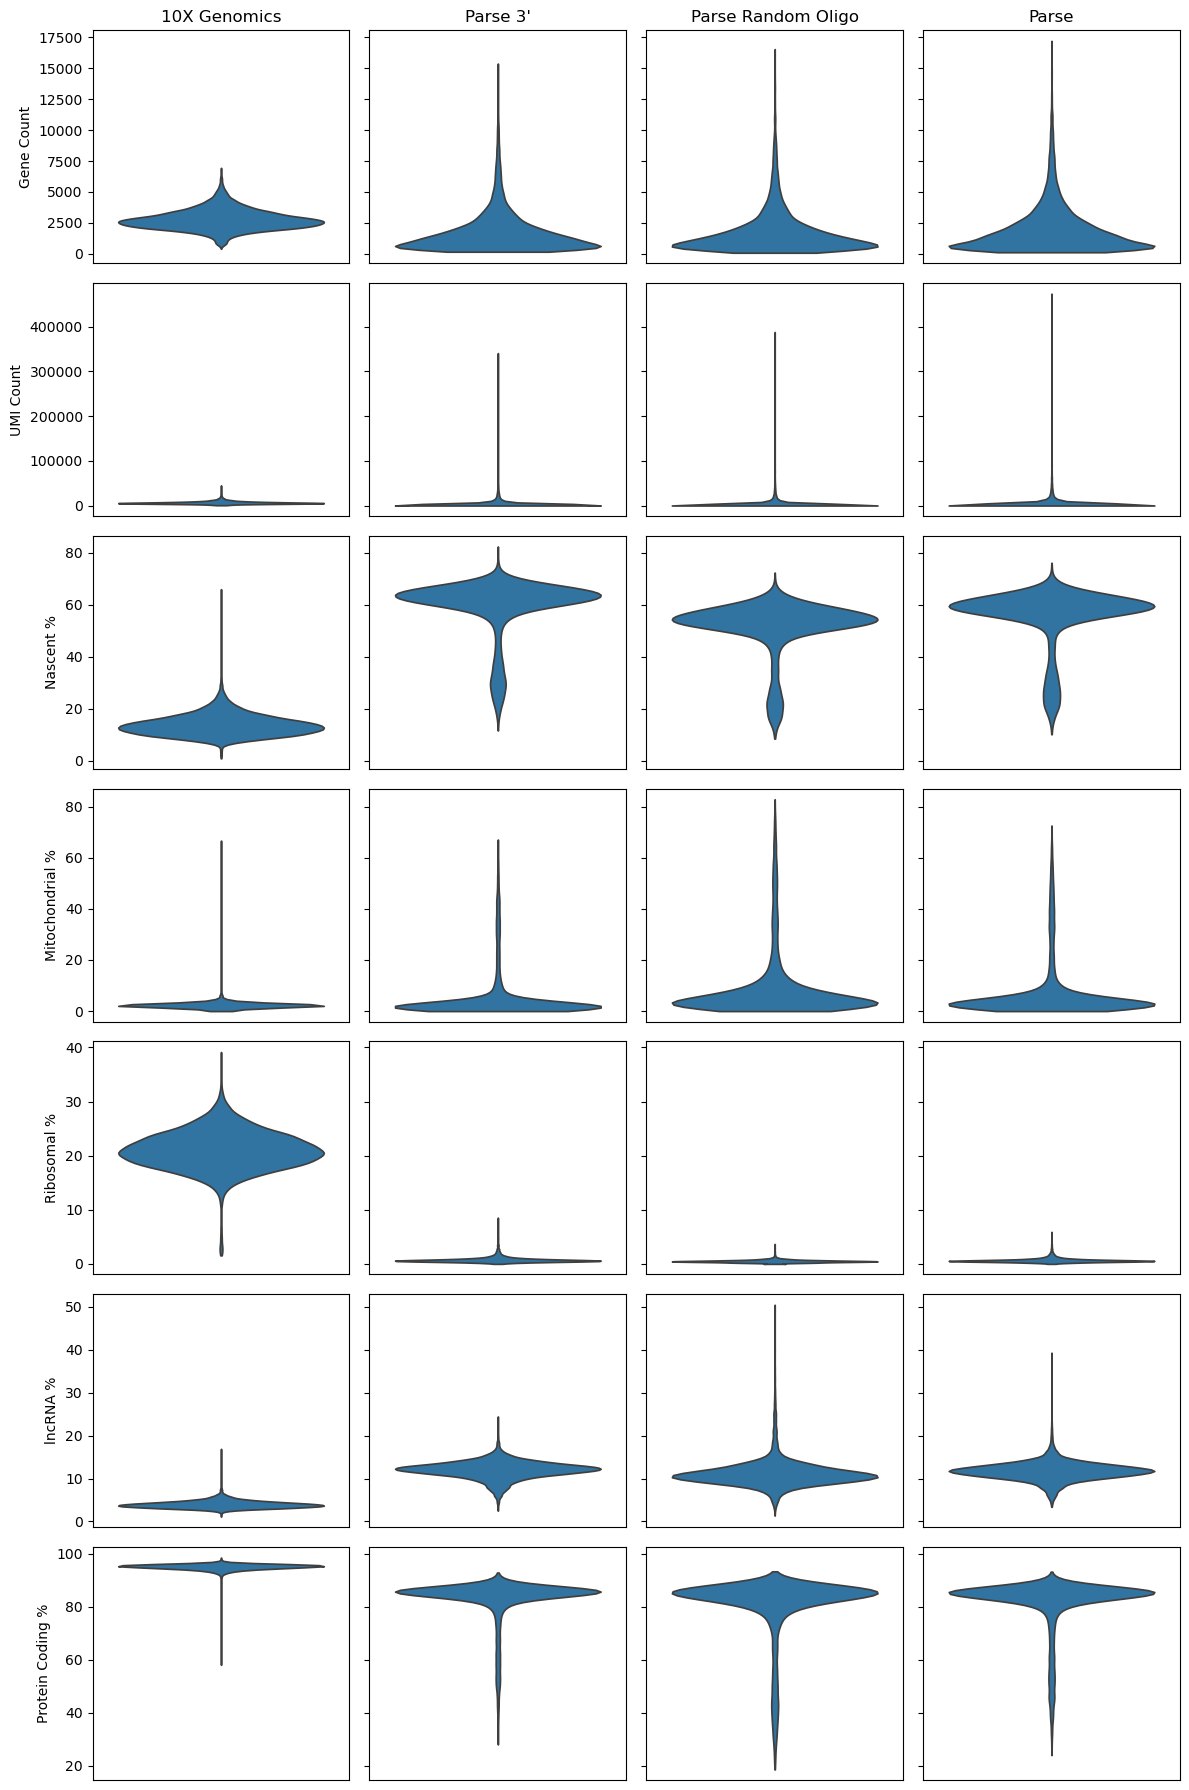

In [ ]:
groups = ['n_genes', 'n_counts', 'percent_nascent', 'percent_mito', 'percent_ribo', 'percent_oxphos', 'percent_lnc', 'percent_pc']
group_names = ['Gene Count', 'UMI Count', 'Nascent %', 'Mitochondrial %', 'Ribosomal %', 'OXPHOS %', 'lncRNA %', 'Protein Coding %']

plotting.plot_cell_metrics(datasets, groups=groups, group_names=group_names)

# Read/Gene Comparisons

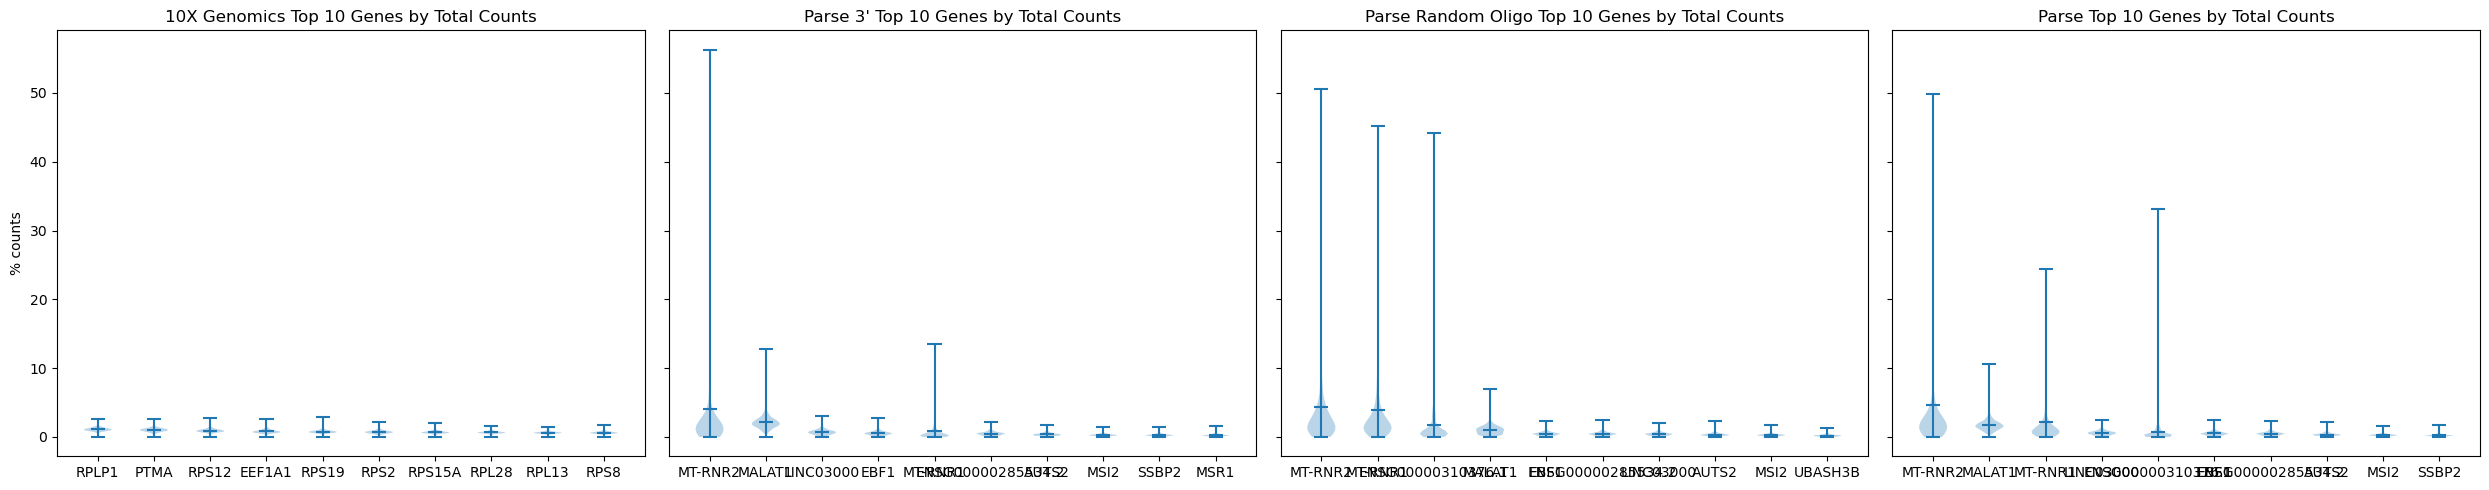

In [17]:
plotting.top_gene_counts(datasets)

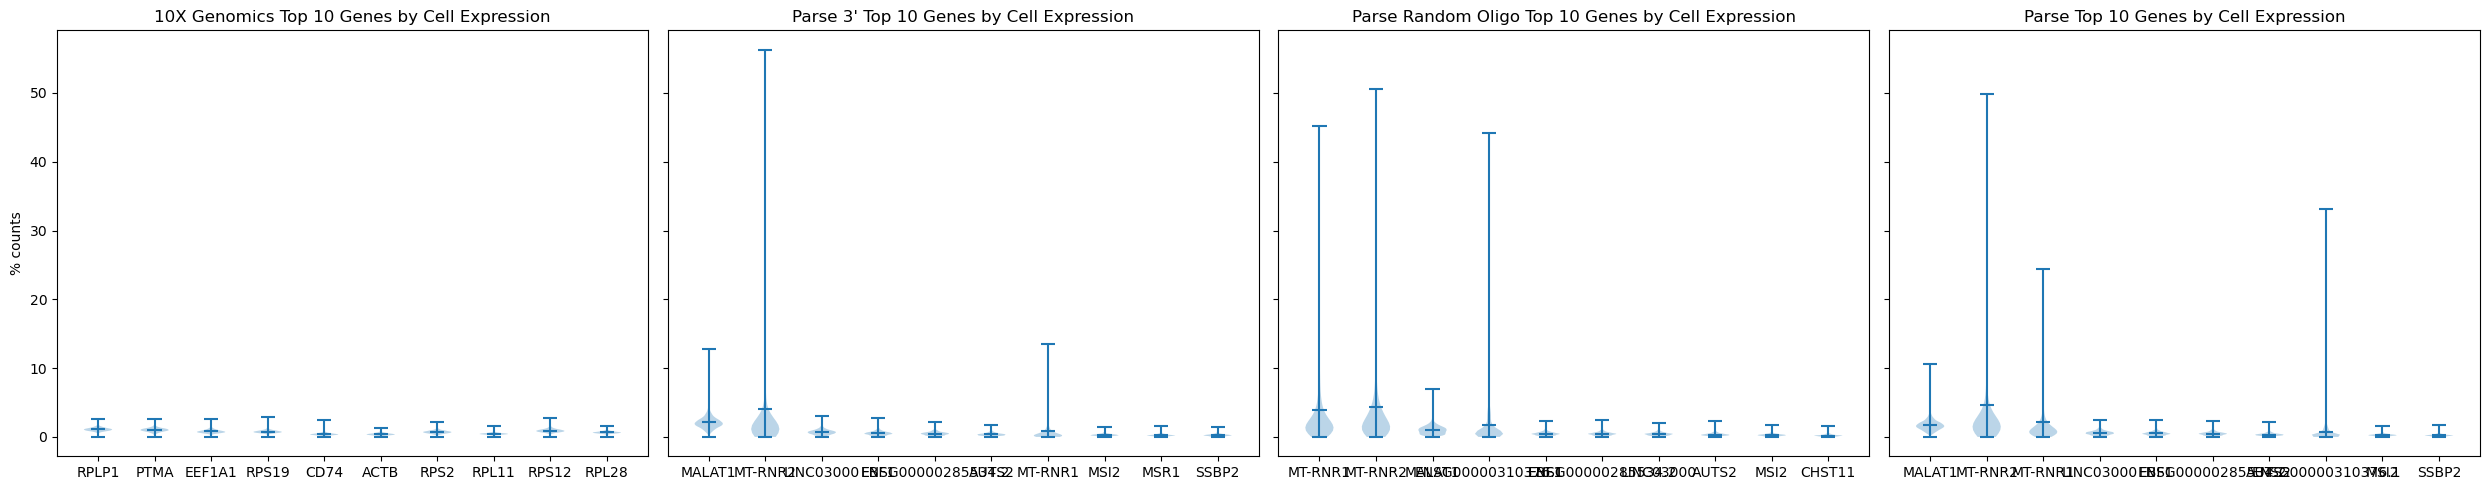

In [18]:
plotting.top_gene_cell_expression(datasets)

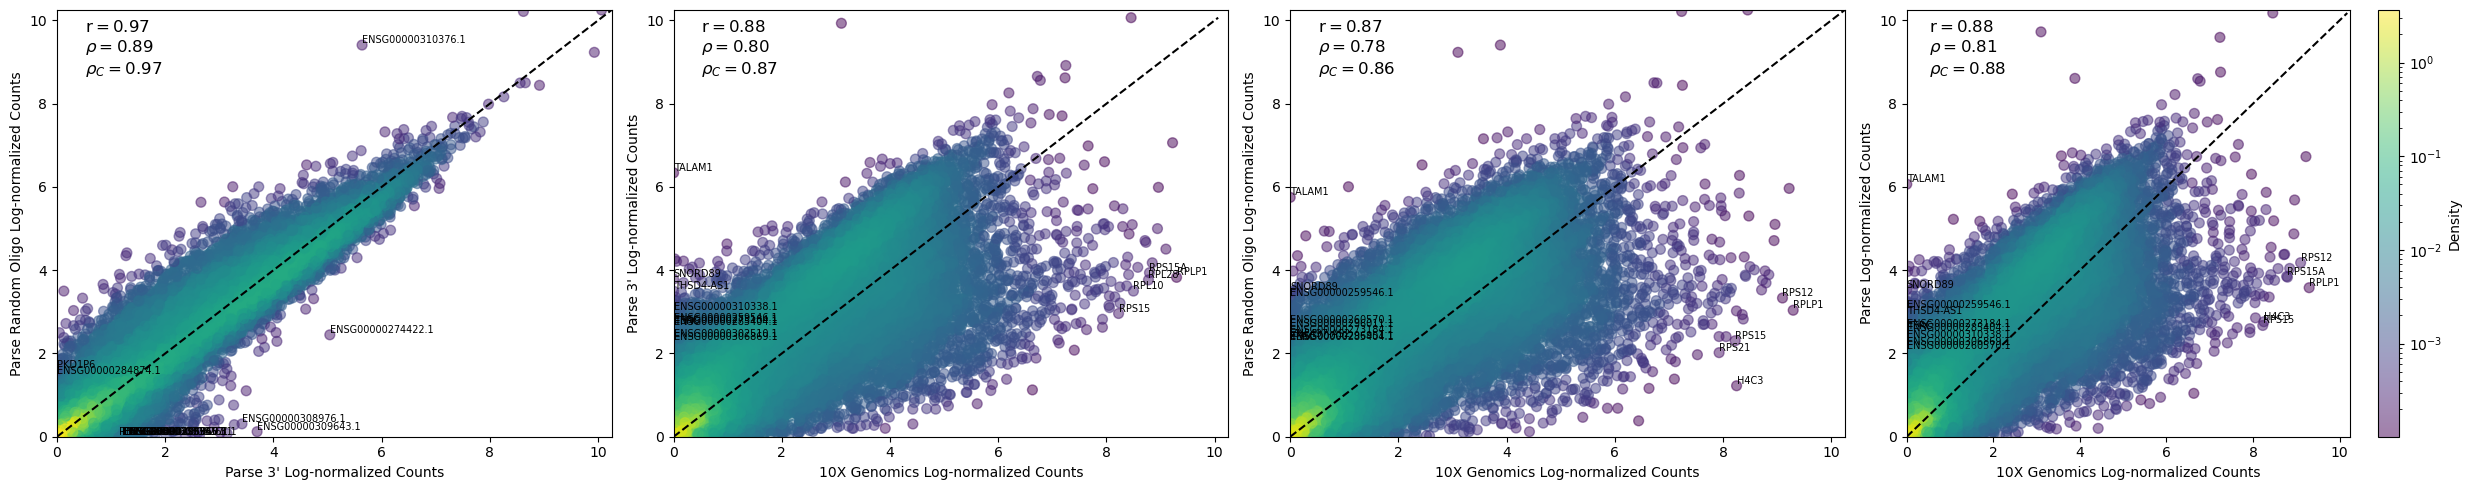

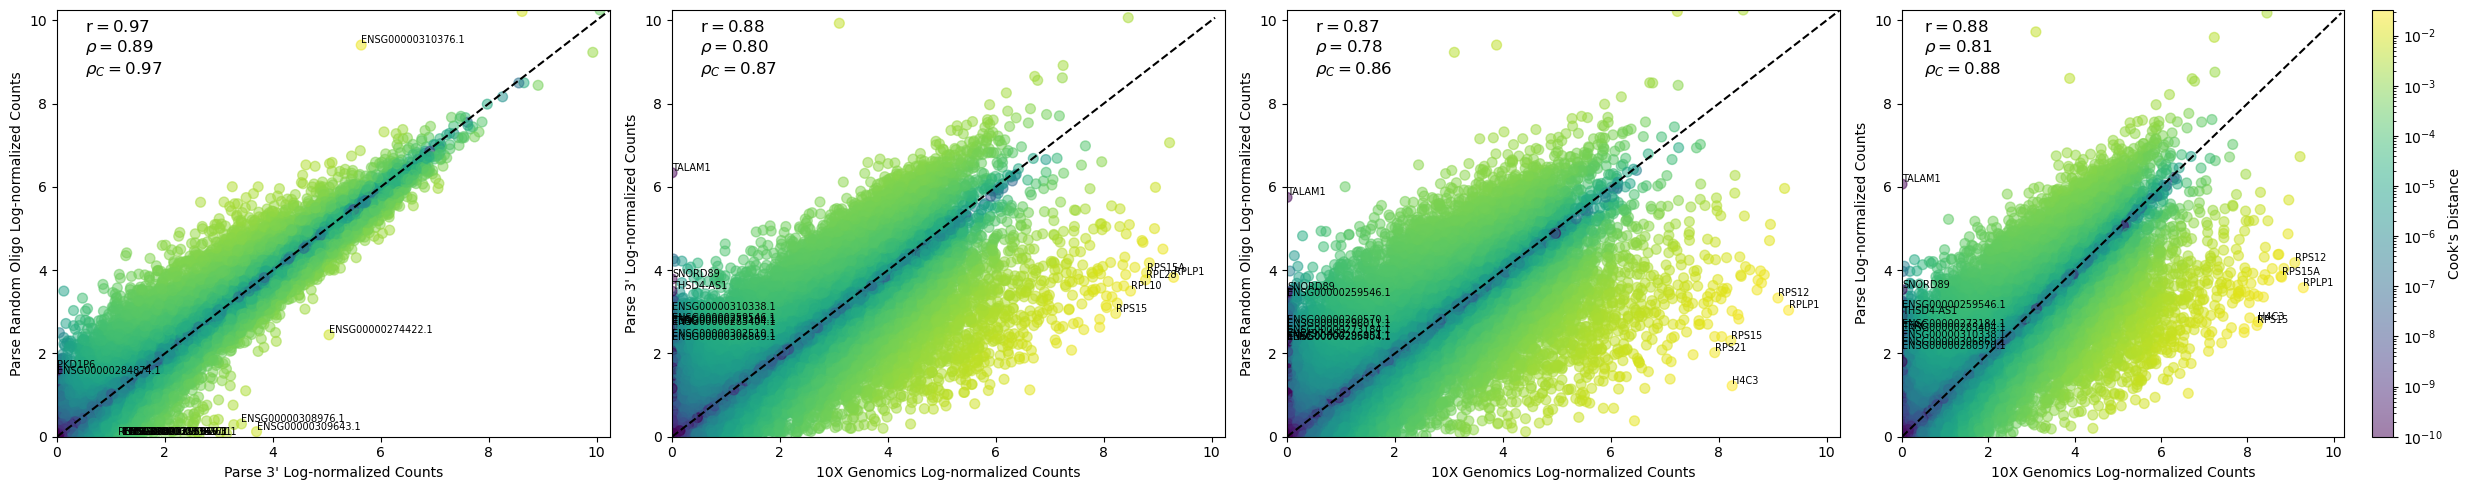

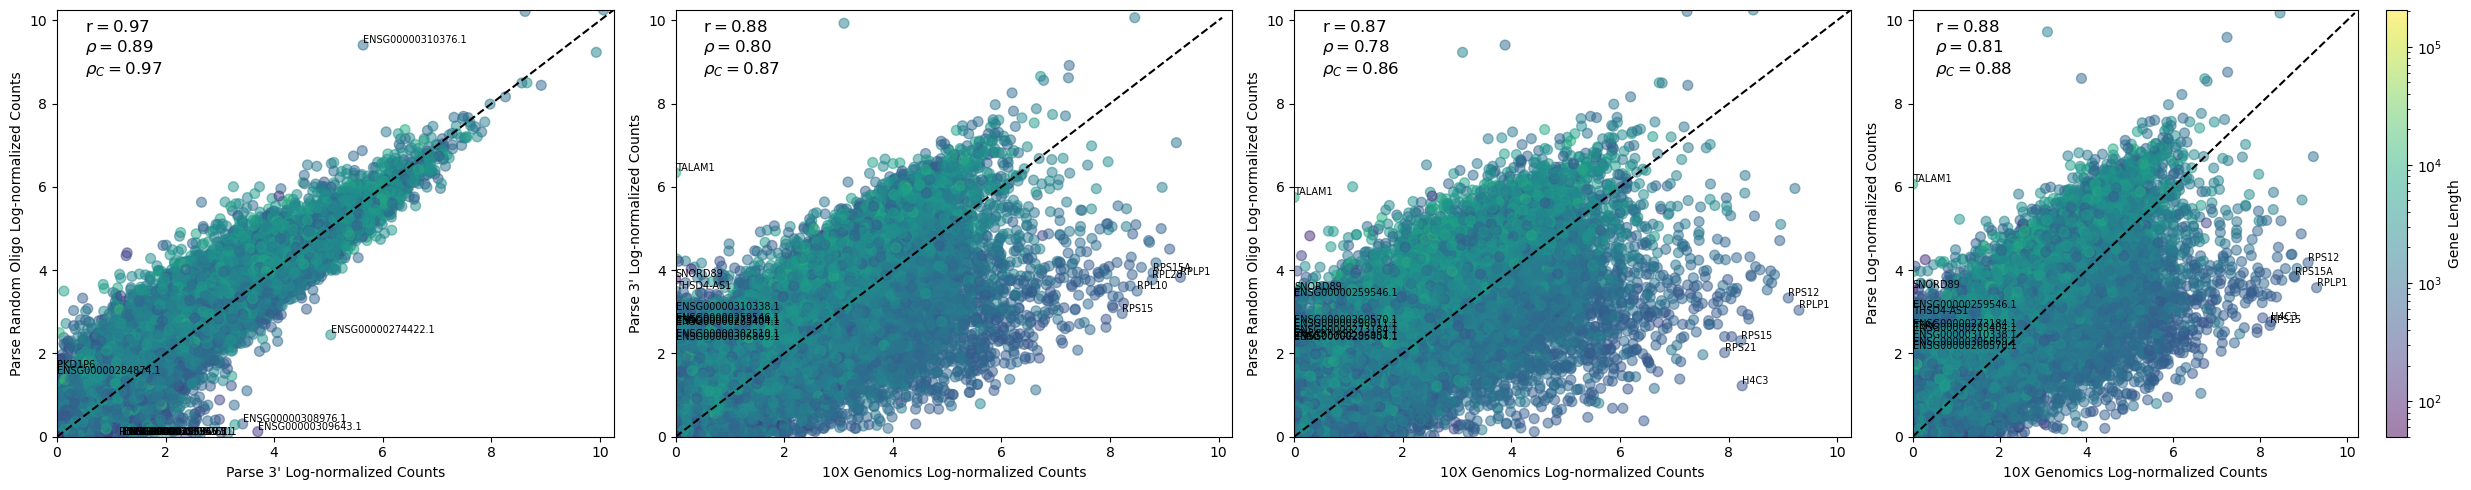

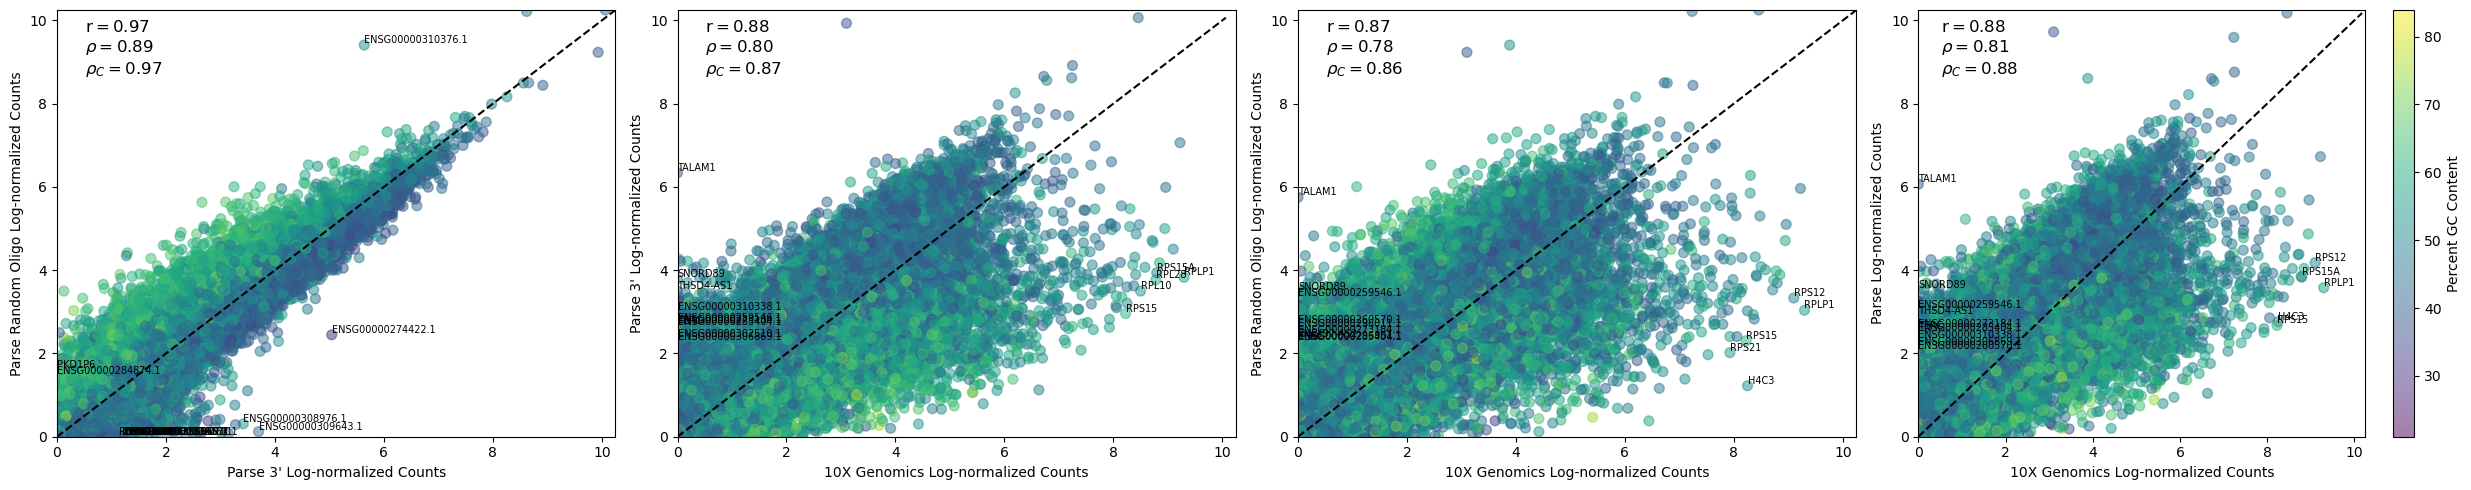

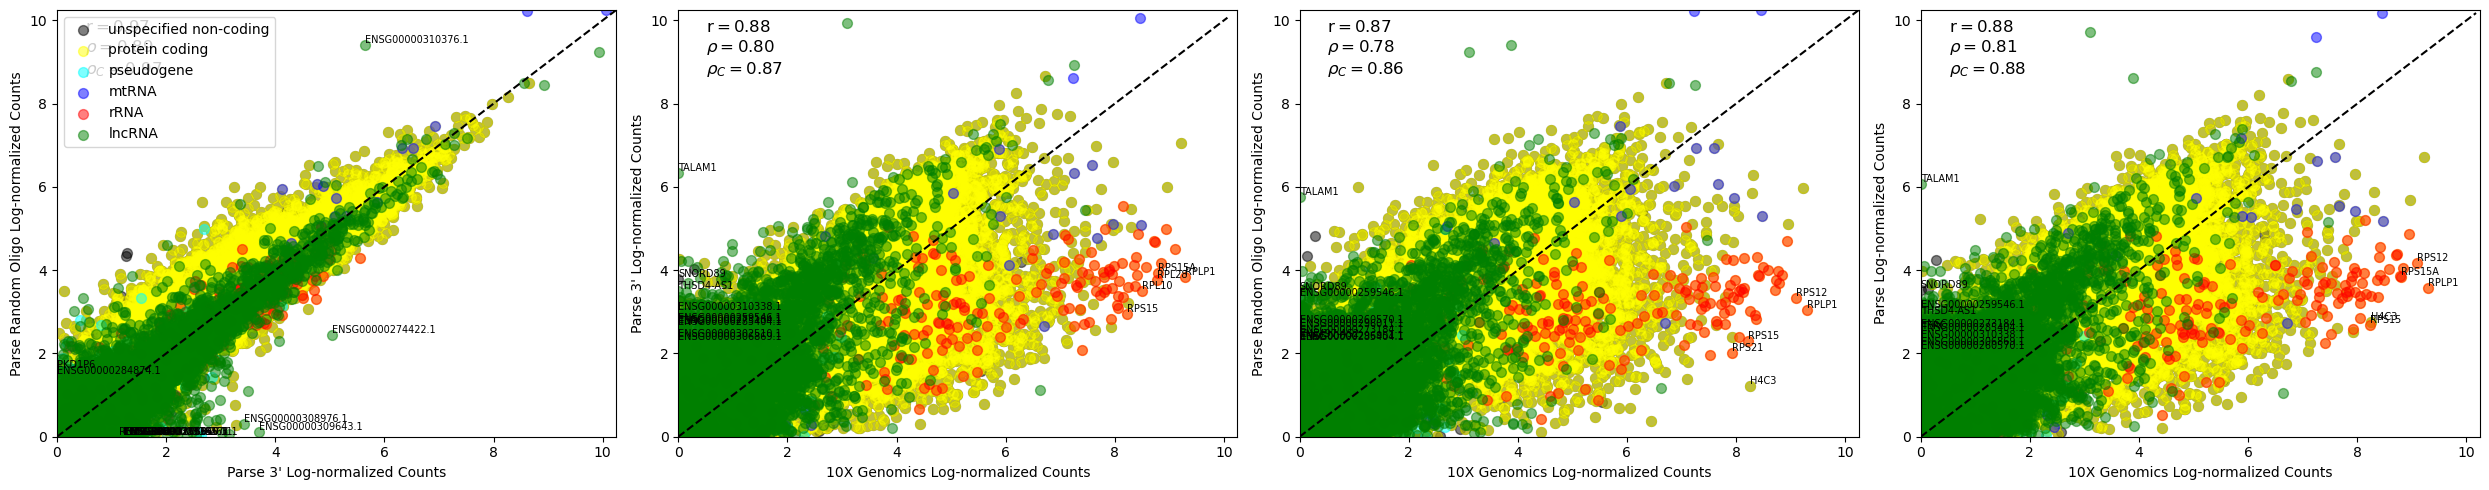

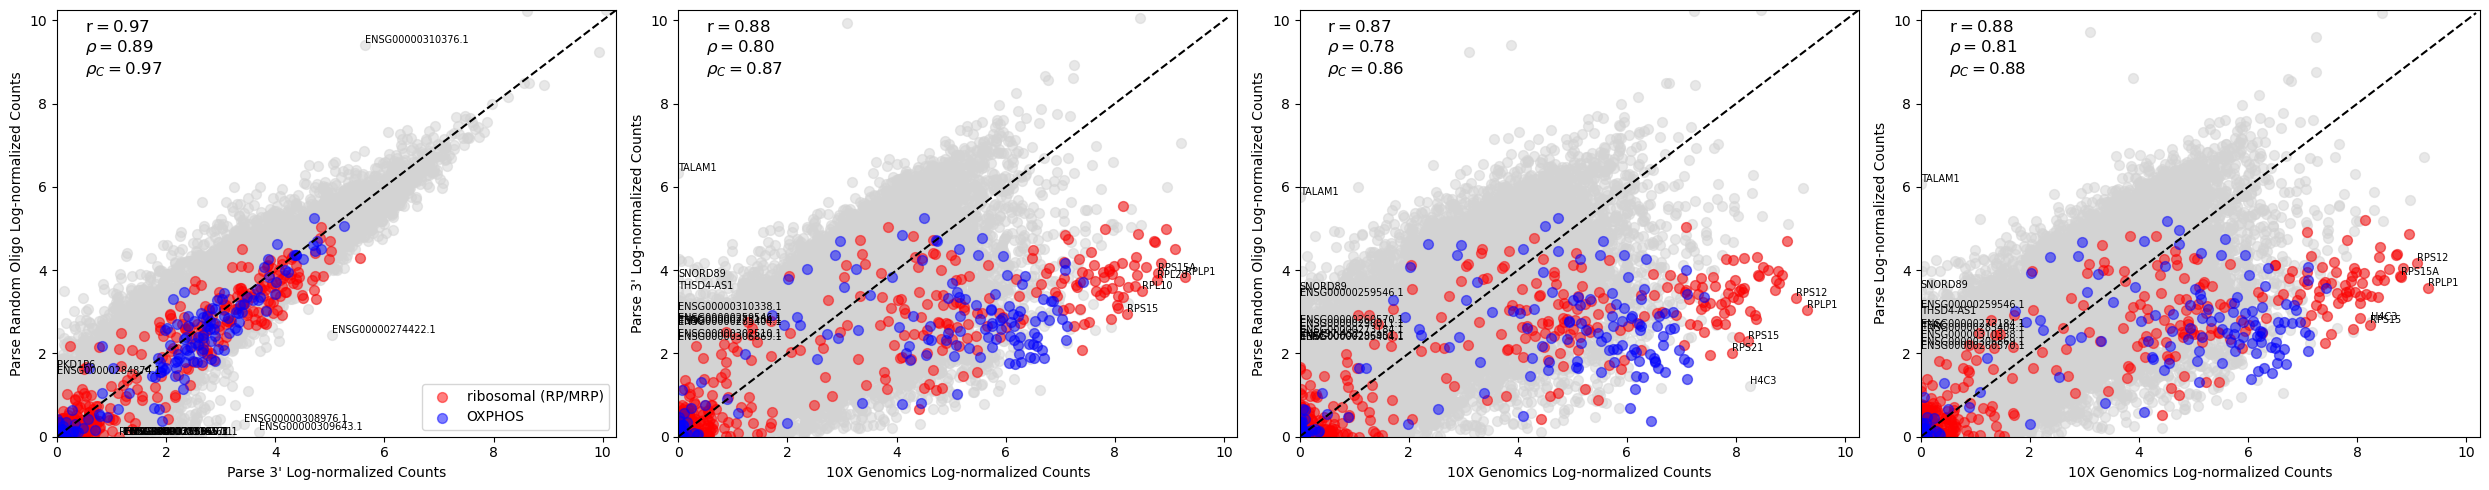

In [19]:
compare_names, compare_dfs = plotting.compare(datasets)


  Parse 3' vs Parse Random Oligo | Cytoplasmic Translation (GO:0002181): 64/89 toward Parse 3', 25/89 toward Parse Random Oligo, p=3.21e-06
  10X Genomics vs Parse 3' | Cytoplasmic Translation (GO:0002181): 89/89 toward 10X Genomics, 0/89 toward Parse 3', p=9.16e-41


  10X Genomics vs Parse Random Oligo | Cytoplasmic Translation (GO:0002181): 89/89 toward 10X Genomics, 0/89 toward Parse Random Oligo, p=3.60e-44
  10X Genomics vs Parse | Cytoplasmic Translation (GO:0002181): 89/89 toward 10X Genomics, 0/89 toward Parse, p=7.43e-44


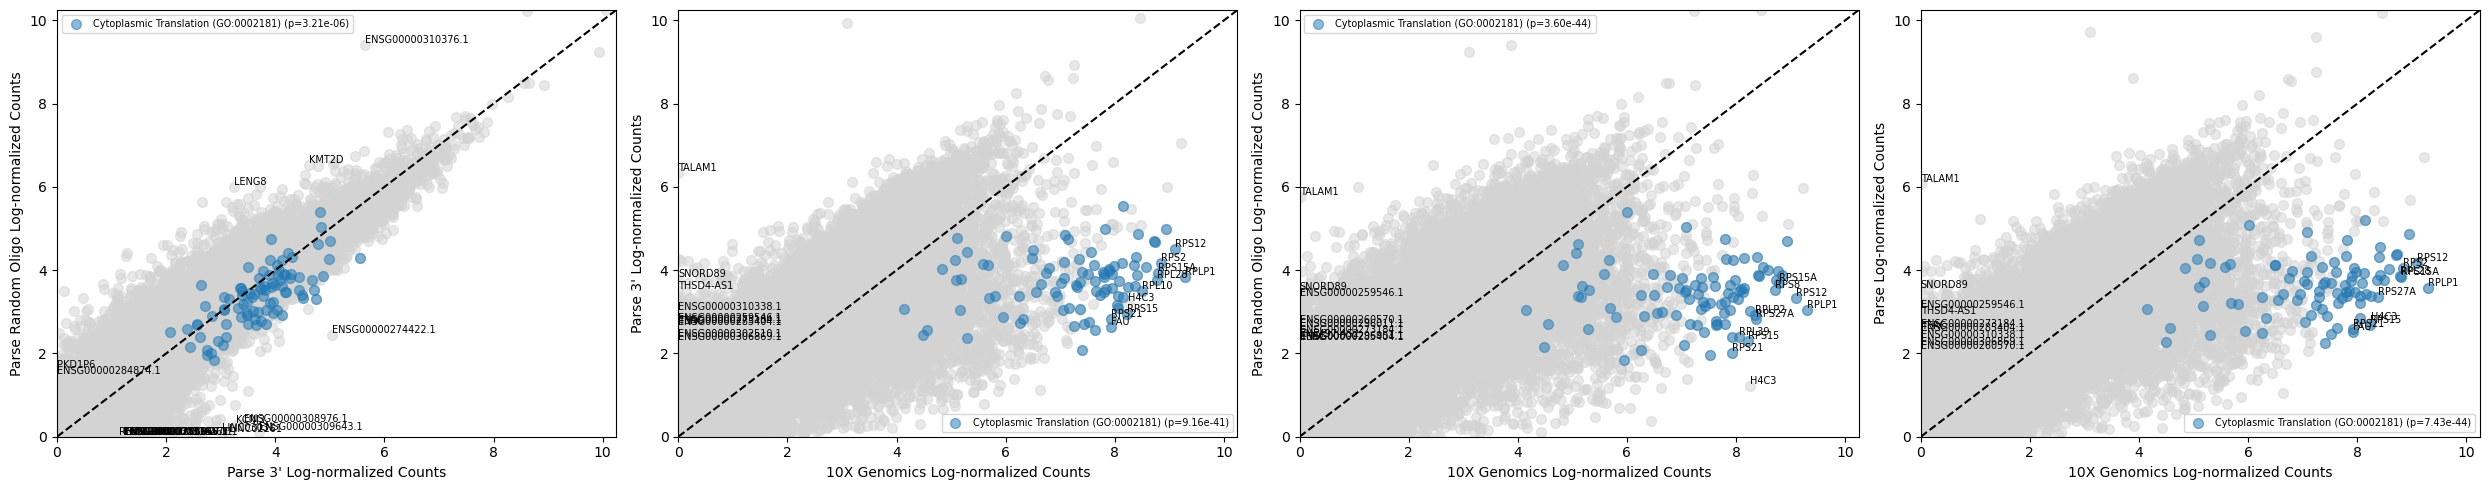

In [20]:
data_10x = datasets[0]
data_polyT = datasets[1]
data_randO = datasets[2]
data_parse = datasets[3]

comparisons = [(data_polyT, data_randO),
                (data_10x, data_polyT),
                (data_10x, data_randO),
                (data_10x, data_parse)]

plotting.compare_by_enrichment(
    compare_dfs, comparisons,
    enrichment_path="/home/mcaskey/10XvParse/Notebooks/Comparisons/10XvParse/10x_outliers/enrichment_results.csv",
    gene_sets=["GO_Biological_Process_2026"],
    terms=["Cytoplasmic Translation (GO:0002181)"]
)

  Parse 3' vs Parse Random Oligo | Oxidative Phosphorylation (GO:0006119): 37/53 toward Parse 3', 16/53 toward Parse Random Oligo, p=1.31e-03
  10X Genomics vs Parse 3' | Oxidative Phosphorylation (GO:0006119): 53/53 toward 10X Genomics, 0/53 toward Parse 3', p=1.43e-24


  10X Genomics vs Parse Random Oligo | Oxidative Phosphorylation (GO:0006119): 53/53 toward 10X Genomics, 0/53 toward Parse Random Oligo, p=1.34e-26
  10X Genomics vs Parse | Oxidative Phosphorylation (GO:0006119): 53/53 toward 10X Genomics, 0/53 toward Parse, p=2.06e-26


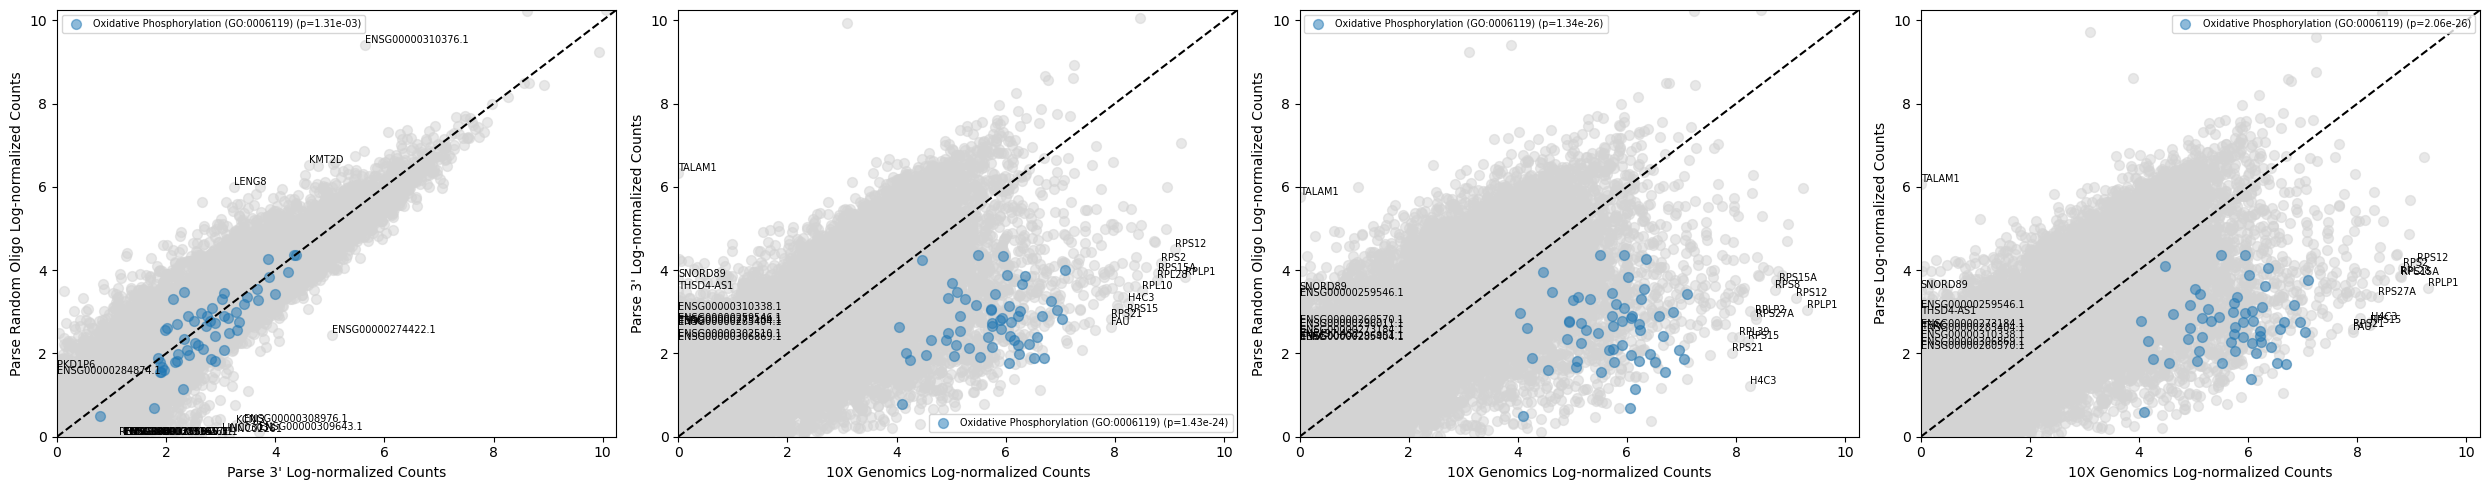

In [21]:
plotting.compare_by_enrichment(
    compare_dfs, comparisons,
    enrichment_path="/home/mcaskey/10XvParse/Notebooks/Comparisons/10XvParse/10x_outliers/enrichment_results.csv",
    gene_sets=["GO_Biological_Process_2026"],
    terms=["Oxidative Phosphorylation (GO:0006119)"])

  Parse 3' vs Parse Random Oligo | Ribosome Biogenesis (GO:0042254): 48/74 toward Parse 3', 26/74 toward Parse Random Oligo, p=3.26e-03
  10X Genomics vs Parse 3' | Ribosome Biogenesis (GO:0042254): 74/74 toward 10X Genomics, 0/74 toward Parse 3', p=4.77e-34


  10X Genomics vs Parse Random Oligo | Ribosome Biogenesis (GO:0042254): 73/74 toward 10X Genomics, 1/74 toward Parse Random Oligo, p=1.09e-34
  10X Genomics vs Parse | Ribosome Biogenesis (GO:0042254): 74/74 toward 10X Genomics, 0/74 toward Parse, p=1.27e-36


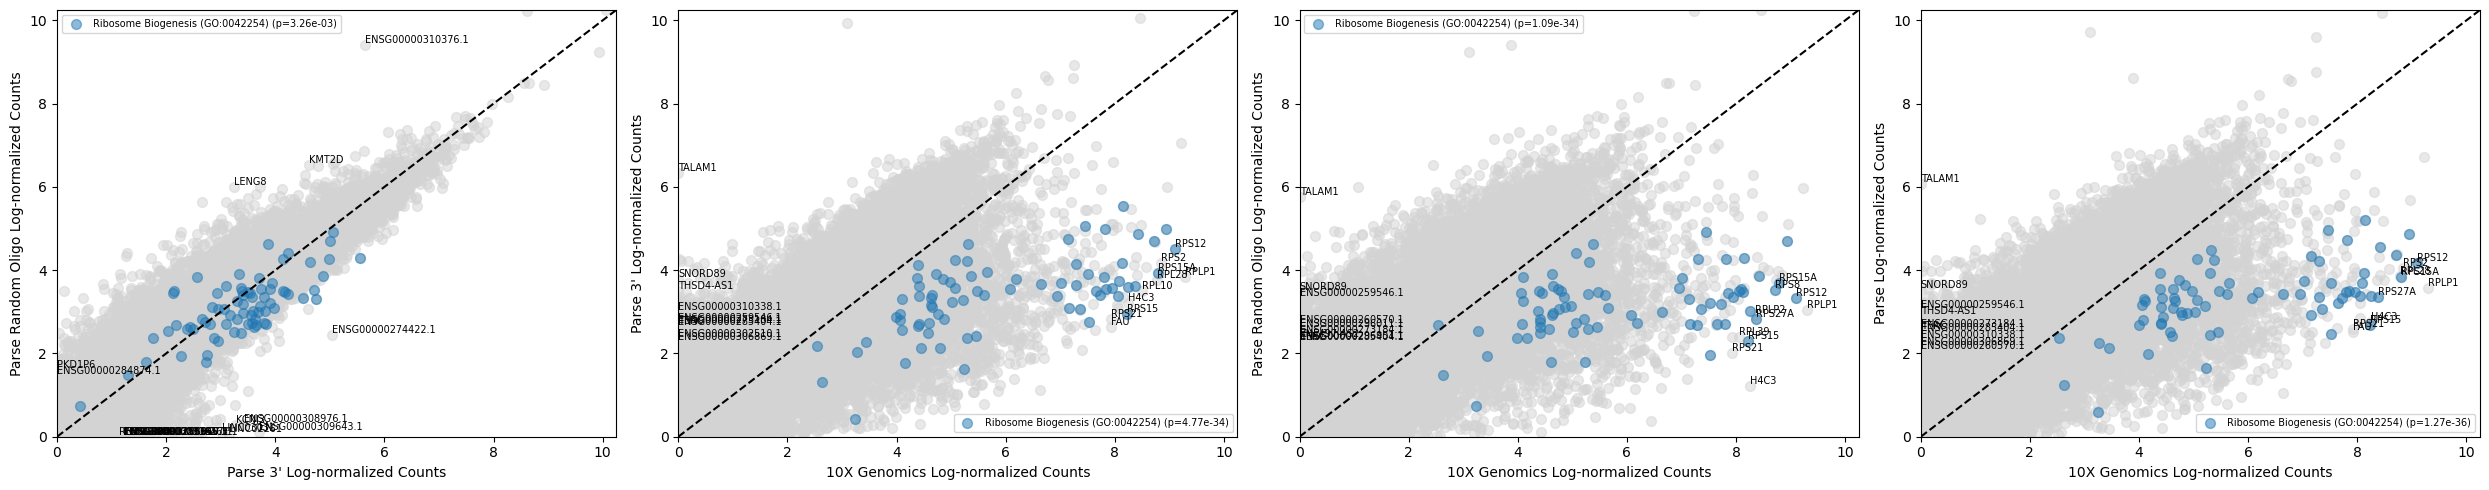

In [22]:
plotting.compare_by_enrichment(
    compare_dfs, comparisons,
    enrichment_path="/home/mcaskey/10XvParse/Notebooks/Comparisons/10XvParse/10x_outliers/enrichment_results.csv",
    gene_sets=["GO_Biological_Process_2026"],
    terms=["Ribosome Biogenesis (GO:0042254)"])

  Parse 3' vs Parse Random Oligo | Mitochondrial Translation (GO:0032543): 37/61 toward Parse 3', 24/61 toward Parse Random Oligo, p=3.99e-02
  10X Genomics vs Parse 3' | Mitochondrial Translation (GO:0032543): 60/61 toward 10X Genomics, 1/61 toward Parse 3', p=3.90e-26


  10X Genomics vs Parse Random Oligo | Mitochondrial Translation (GO:0032543): 61/61 toward 10X Genomics, 0/61 toward Parse Random Oligo, p=1.60e-30
  10X Genomics vs Parse | Mitochondrial Translation (GO:0032543): 60/61 toward 10X Genomics, 1/61 toward Parse, p=3.34e-28


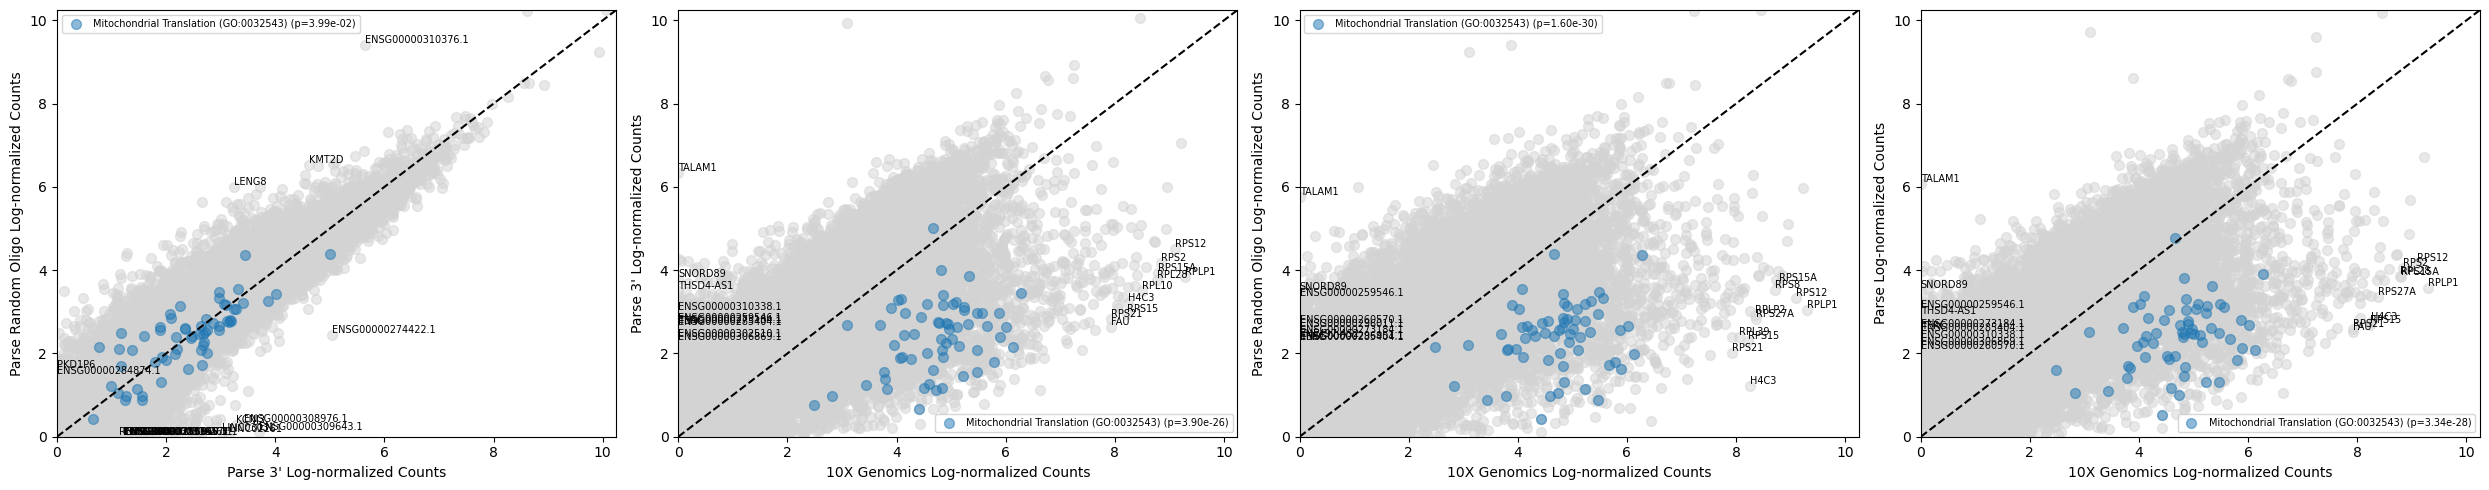

In [23]:
plotting.compare_by_enrichment(
    compare_dfs, comparisons,
    enrichment_path="/home/mcaskey/10XvParse/Notebooks/Comparisons/10XvParse/10x_outliers/enrichment_results.csv",
    gene_sets=["GO_Biological_Process_2026"],
    terms=["Mitochondrial Translation (GO:0032543)"])

  Parse 3' vs Parse Random Oligo | Mitochondrial Respiratory Chain Complex Assembly (GO:0033108): 32/55 toward Parse 3', 23/55 toward Parse Random Oligo, p=1.36e-01
  10X Genomics vs Parse 3' | Mitochondrial Respiratory Chain Complex Assembly (GO:0033108): 54/55 toward 10X Genomics, 1/55 toward Parse 3', p=1.81e-23


  10X Genomics vs Parse Random Oligo | Mitochondrial Respiratory Chain Complex Assembly (GO:0033108): 53/55 toward 10X Genomics, 2/55 toward Parse Random Oligo, p=9.25e-24
  10X Genomics vs Parse | Mitochondrial Respiratory Chain Complex Assembly (GO:0033108): 54/55 toward 10X Genomics, 1/55 toward Parse, p=2.51e-25


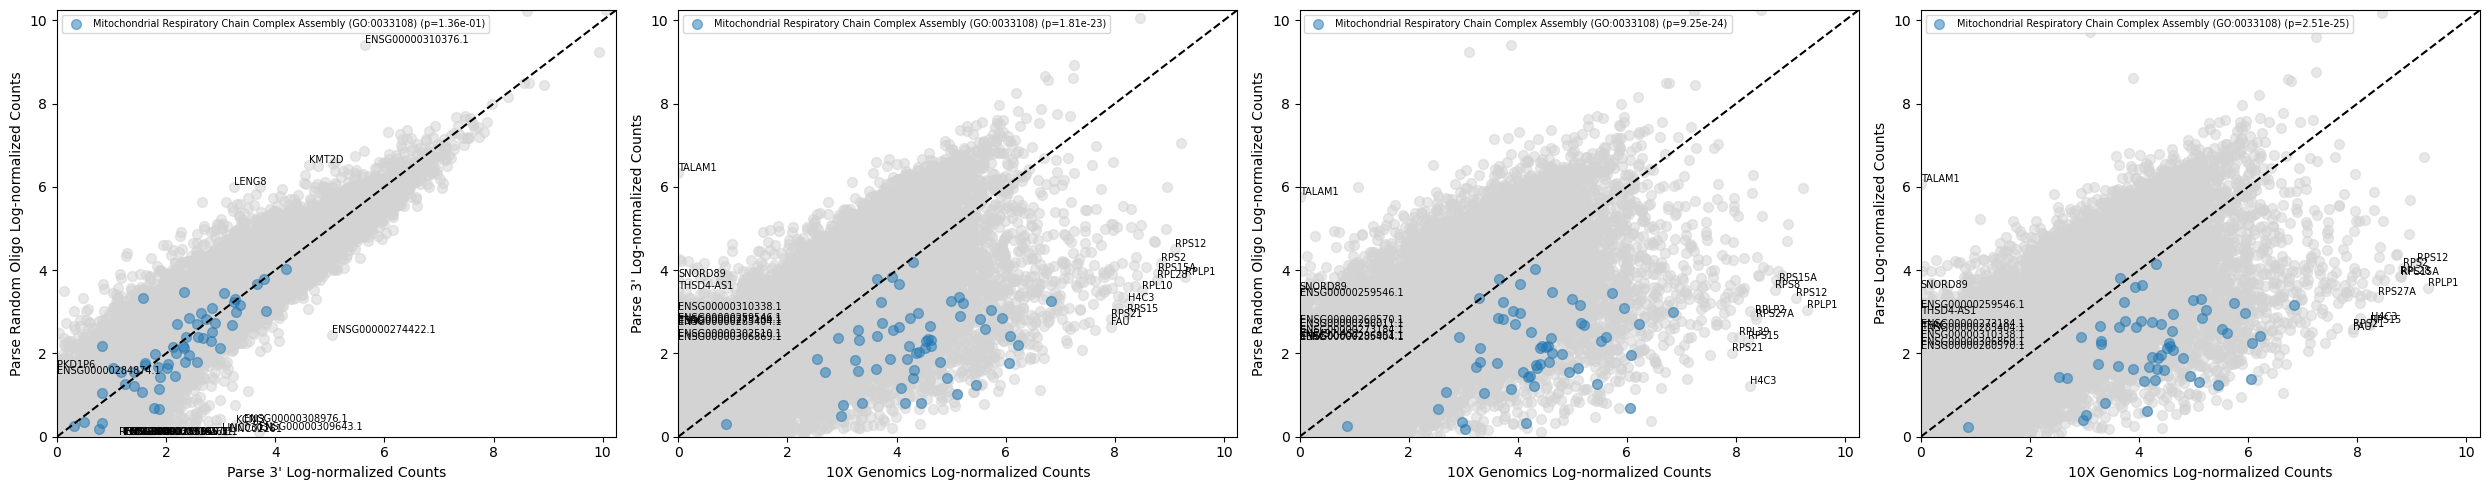

In [24]:
plotting.compare_by_enrichment(
    compare_dfs, comparisons,
    enrichment_path="/home/mcaskey/10XvParse/Notebooks/Comparisons/10XvParse/10x_outliers/enrichment_results.csv",
    gene_sets=["GO_Biological_Process_2026"],
    terms=["Mitochondrial Respiratory Chain Complex Assembly (GO:0033108)"])

/home/mcaskey/10XvParse/XvP_utils/plotting/processing.py:250: UserWarning: compare_by_enrichment: 6 genes in "Extracellular Exosome (GO:0070062)" but missing from data:
  ['CTSF', 'FCGR3A', 'HSPA6', 'KRT2', 'PTGDS', 'S100A8']
  warnings.warn(


  Parse 3' vs Parse Random Oligo | Mitochondrial Inner Membrane (GO:0005743): 138/218 toward Parse 3', 80/218 toward Parse Random Oligo, p=2.11e-06
  Parse 3' vs Parse Random Oligo | Large Ribosomal Subunit (GO:0015934): 36/51 toward Parse 3', 15/51 toward Parse Random Oligo, p=1.05e-03
  Parse 3' vs Parse Random Oligo | Extracellular Exosome (GO:0070062): 214/452 toward Parse 3', 238/452 toward Parse Random Oligo, p=1.00e+00
  10X Genomics vs Parse 3' | Mitochondrial Inner Membrane (GO:0005743): 213/218 toward 10X Genomics, 5/218 toward Parse 3', p=1.05e-88
  10X Genomics vs Parse 3' | Large Ribosomal Subunit (GO:0015934): 51/51 toward 10X Genomics, 0/51 toward Parse 3', p=1.23e-23
  10X Genomics vs Parse 3' | Extracellular Exosome (GO:0070062): 420/456 toward 10X Genomics, 36/456 toward Parse 3', p=5.41e-146


  10X Genomics vs Parse Random Oligo | Mitochondrial Inner Membrane (GO:0005743): 213/218 toward 10X Genomics, 5/218 toward Parse Random Oligo, p=7.22e-97
  10X Genomics vs Parse Random Oligo | Large Ribosomal Subunit (GO:0015934): 51/51 toward 10X Genomics, 0/51 toward Parse Random Oligo, p=1.39e-25
  10X Genomics vs Parse Random Oligo | Extracellular Exosome (GO:0070062): 419/454 toward 10X Genomics, 35/454 toward Parse Random Oligo, p=2.68e-162
  10X Genomics vs Parse | Mitochondrial Inner Membrane (GO:0005743): 214/218 toward 10X Genomics, 4/218 toward Parse, p=4.55e-98
  10X Genomics vs Parse | Large Ribosomal Subunit (GO:0015934): 51/51 toward 10X Genomics, 0/51 toward Parse, p=2.10e-25
  10X Genomics vs Parse | Extracellular Exosome (GO:0070062): 422/455 toward 10X Genomics, 33/455 toward Parse, p=4.04e-164


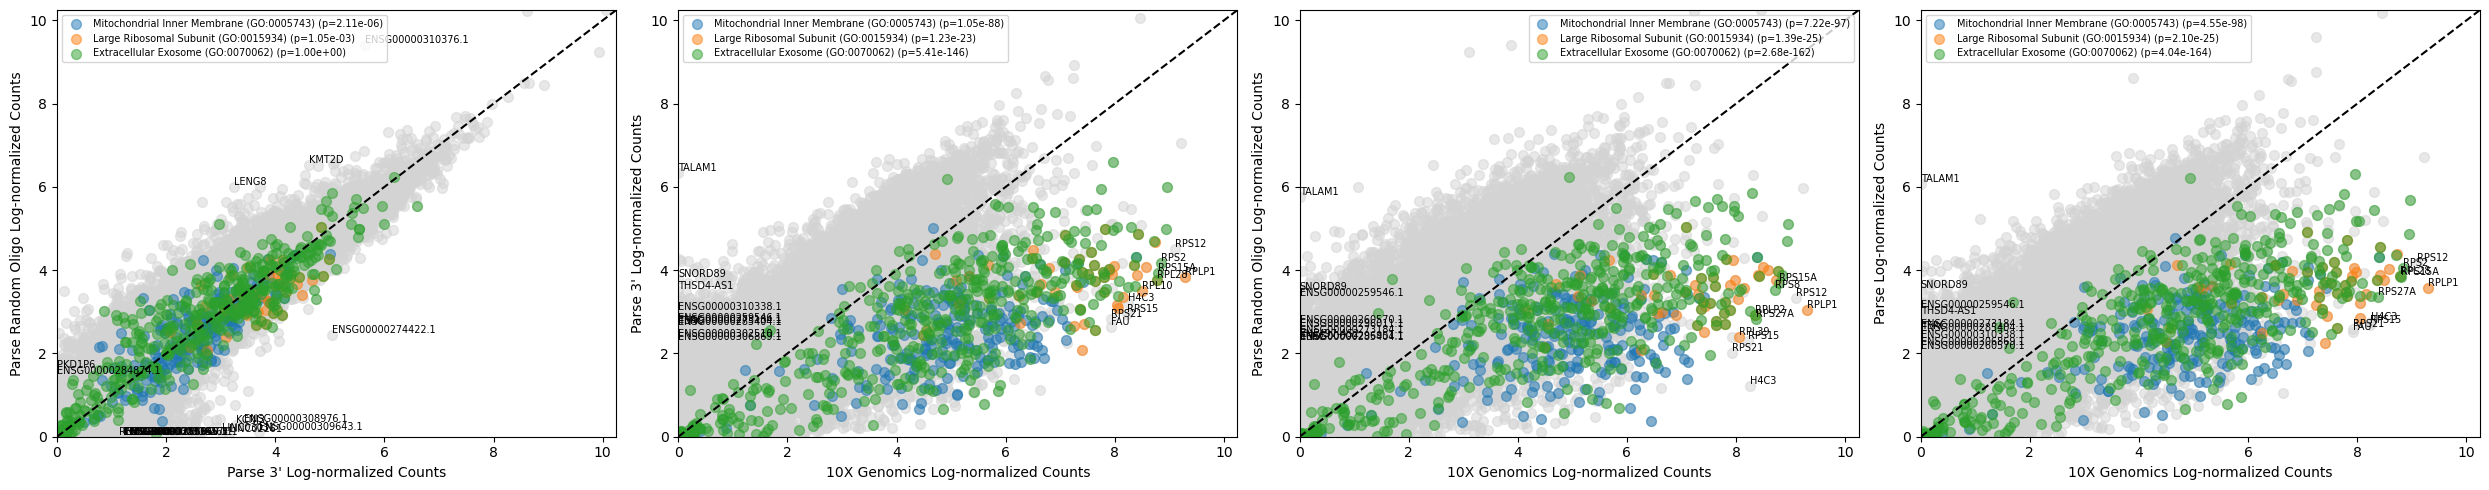

In [25]:
plotting.compare_by_enrichment(
    compare_dfs, comparisons,
    enrichment_path="/home/mcaskey/10XvParse/Notebooks/Comparisons/10XvParse/10x_outliers/enrichment_results.csv",
    gene_sets=["GO_Cellular_Component_2026"],
    terms=["Extracellular Exosome (GO:0070062)", "Large Ribosomal Subunit (GO:0015934)", "Mitochondrial Inner Membrane (GO:0005743)"])

/home/mcaskey/10XvParse/XvP_utils/plotting/combo_plots.py:883: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7)
/home/mcaskey/10XvParse/XvP_utils/plotting/combo_plots.py:883: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7)


/home/mcaskey/10XvParse/XvP_utils/plotting/combo_plots.py:883: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7)
/home/mcaskey/10XvParse/XvP_utils/plotting/combo_plots.py:883: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7)


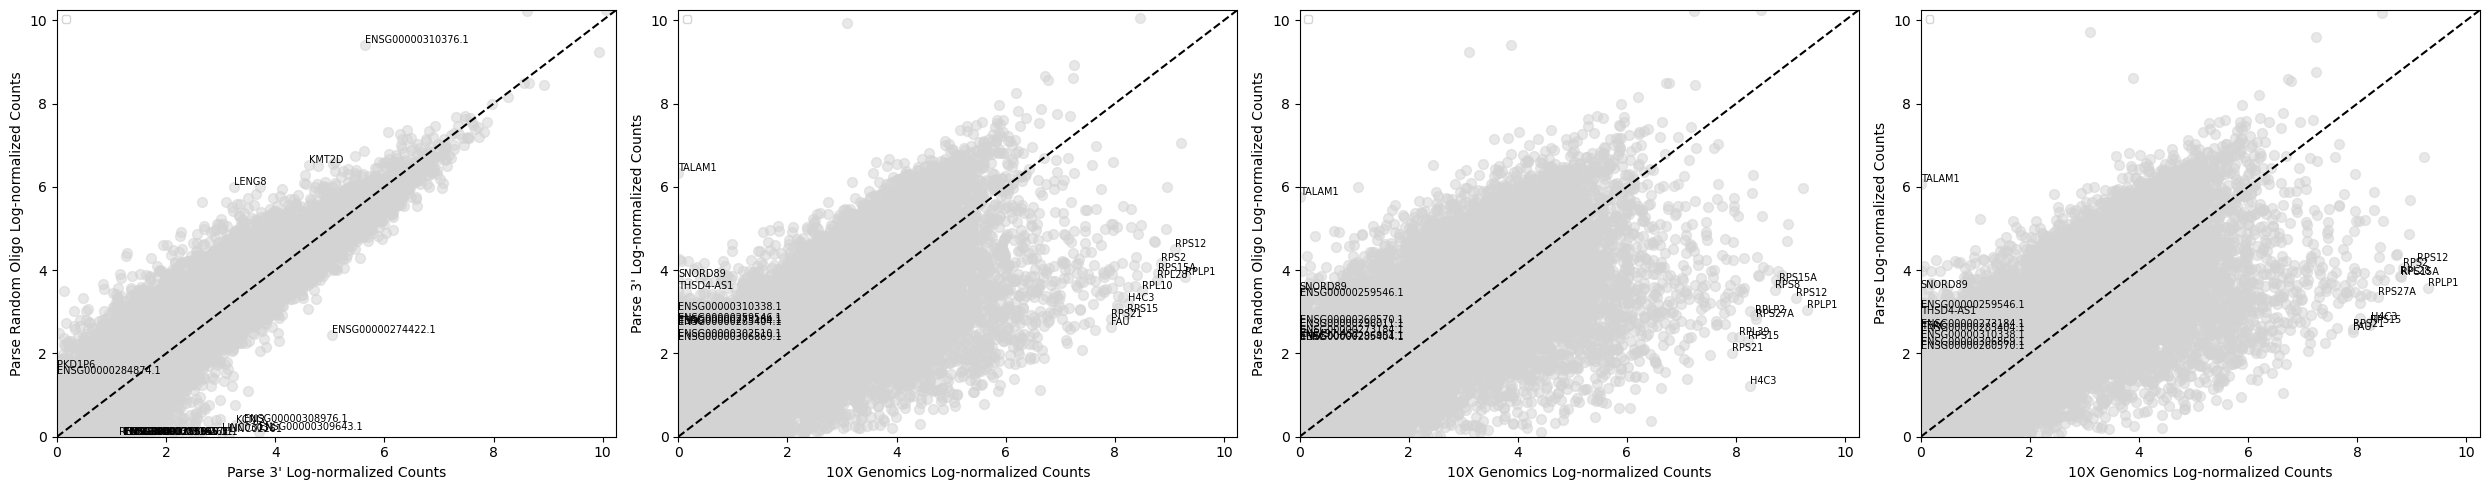

In [26]:
plotting.compare_by_enrichment(
    compare_dfs, comparisons,
    enrichment_path="/home/mcaskey/10XvParse/Notebooks/important_gene_sets.csv",
    gene_sets=["Housekeeping"],
    terms=["Human"])

In [27]:
for name, df in zip(compare_names, compare_dfs):
    gene_info = plotting.merge_by_cooks(gene_info, name, df)
gene_info.to_csv(FULL_GENE_INFO_PATH)